# Churn Risk Scoring — Exploratory Data Analysis

This notebook explores the IBM Telco Customer Churn dataset, framed as a real churn problem
for an Australian telecommunications operator.

The goal is not just to understand the data statistically, but to extract actionable business
insights that will drive modelling decisions and retention strategy recommendations.

**Dataset:** 7,043 customer records, 21 variables  
**Target:** `Churn` — whether a customer left in the last month  
**Business context:** At an ARPU (Average Revenue per User) of AUD $65/month, every percentage point of churn
represents ~$4,578 in monthly recurring revenue at risk.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option("display.max_columns", None)

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

/Users/robertogarces/miniforge3/envs/churn-risk-scoring/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. First Look

In [4]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
Payme

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Quality Fixes

Two issues detected:
- `TotalCharges` is stored as `object` due to whitespace values masking nulls
- `Churn` is stored as `Yes`/`No` strings instead of binary

We convert both before any analysis.

In [6]:
# TotalCharges contains whitespace strings disguised as nulls
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Real nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"\nRecords with null TotalCharges:\n")
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Real nulls in TotalCharges: 11

Records with null TotalCharges:



,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


All 11 null records have `tenure = 0` — these are brand new customers with no payment history yet.
This is a valid business state, not a data error. We impute with 0.

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0).astype(float)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Remaining nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Remaining nulls in TotalCharges: 0

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 3. Churn Rate Overview

At **26.5% churn rate**, the operator is losing more than 1 in 4 customers.  
Industry benchmark for telco is 12–24% annually — this dataset sits at the high end.

1,869 customers flagged as churned in the observation period. At AUD $65 ARPU, this represents ~$121,485 in lost monthly recurring revenue if no retention action is taken

Class imbalance (73.5% / 26.5%) is moderate — manageable without aggressive resampling,
but we'll use `class_weight='balanced'` in the model.

## 4. Numerical Features

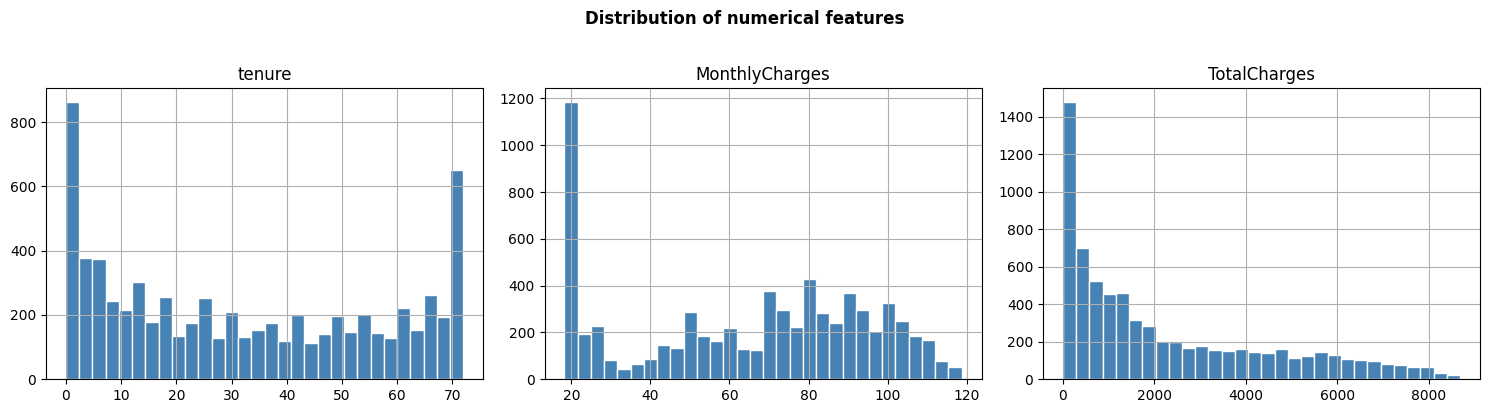

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Distribution of numerical features', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**tenure** — Bimodal distribution: spike at 0–5 months (new customers) and at 70–72 months
(long-term customers). The middle is sparse — customers either leave early or stay long-term.

**MonthlyCharges** — Multimodal, reflecting plan segmentation: basic (~$20), mid (~$50),
and premium (~$80–90) tiers.

**TotalCharges** — Heavily right-skewed, a direct consequence of tenure distribution.
Likely redundant as a feature given its 0.83 correlation with tenure.

### 4.1 Numerical Features by Churn

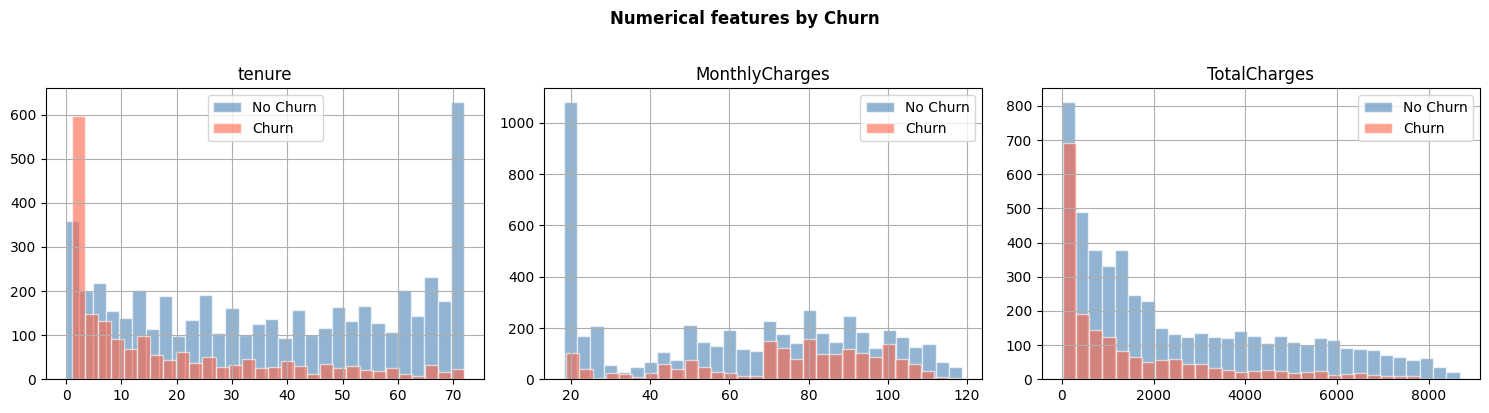

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[df['Churn'] == 0][col].hist(bins=30, ax=ax, alpha=0.6, label='No Churn', color='steelblue', edgecolor='white')
    df[df['Churn'] == 1][col].hist(bins=30, ax=ax, alpha=0.6, label='Churn', color='tomato', edgecolor='white')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Numerical features by Churn', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**tenure** — Churn is almost entirely concentrated in the first 5 months.
Customers beyond 5 years show near-zero churn. Retention efforts should focus on onboarding
and the first 12 months.

**MonthlyCharges** — Churned customers skew toward higher charges ($70–$120).
Premium plan customers have more alternatives and higher price sensitivity.

**TotalCharges** — Pattern mirrors tenure, confirming it carries no independent information.
Candidate for removal in feature engineering.

## 5. Categorical Features
### 5.1 Key Business Variables

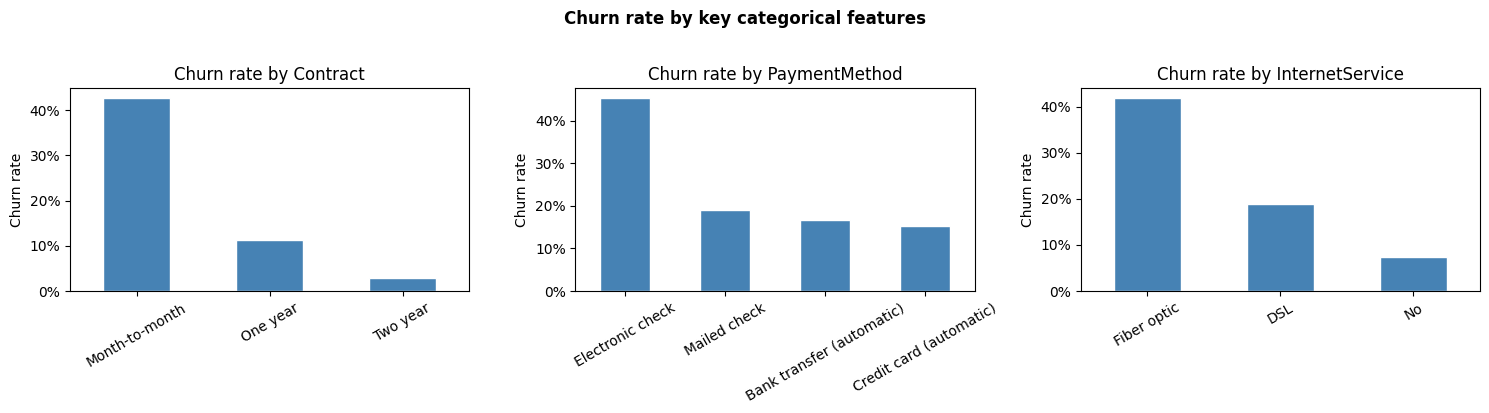

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Contract', 'PaymentMethod', 'InternetService']):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Churn rate by key categorical features', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**Contract** — Strongest single predictor. Month-to-month: **42.7%** churn vs Two-year: **2.8%** (15x difference).
Zero contractual friction means zero barrier to leave. The clearest retention lever is
incentivising upgrades to annual or two-year contracts.

**PaymentMethod** — Electronic check: **45.3%** churn vs automatic methods: ~15–16%.
Automatic payments create inertia. Manual payment methods keep customers actively aware
of what they're spending — increasing cancellation intent.

**InternetService** — Fiber optic: **41.9%** churn despite being the premium tier.
This is the most commercially dangerous segment: highest ARPU and highest churn risk simultaneously.

### 5.2 Remaining Categorical Features

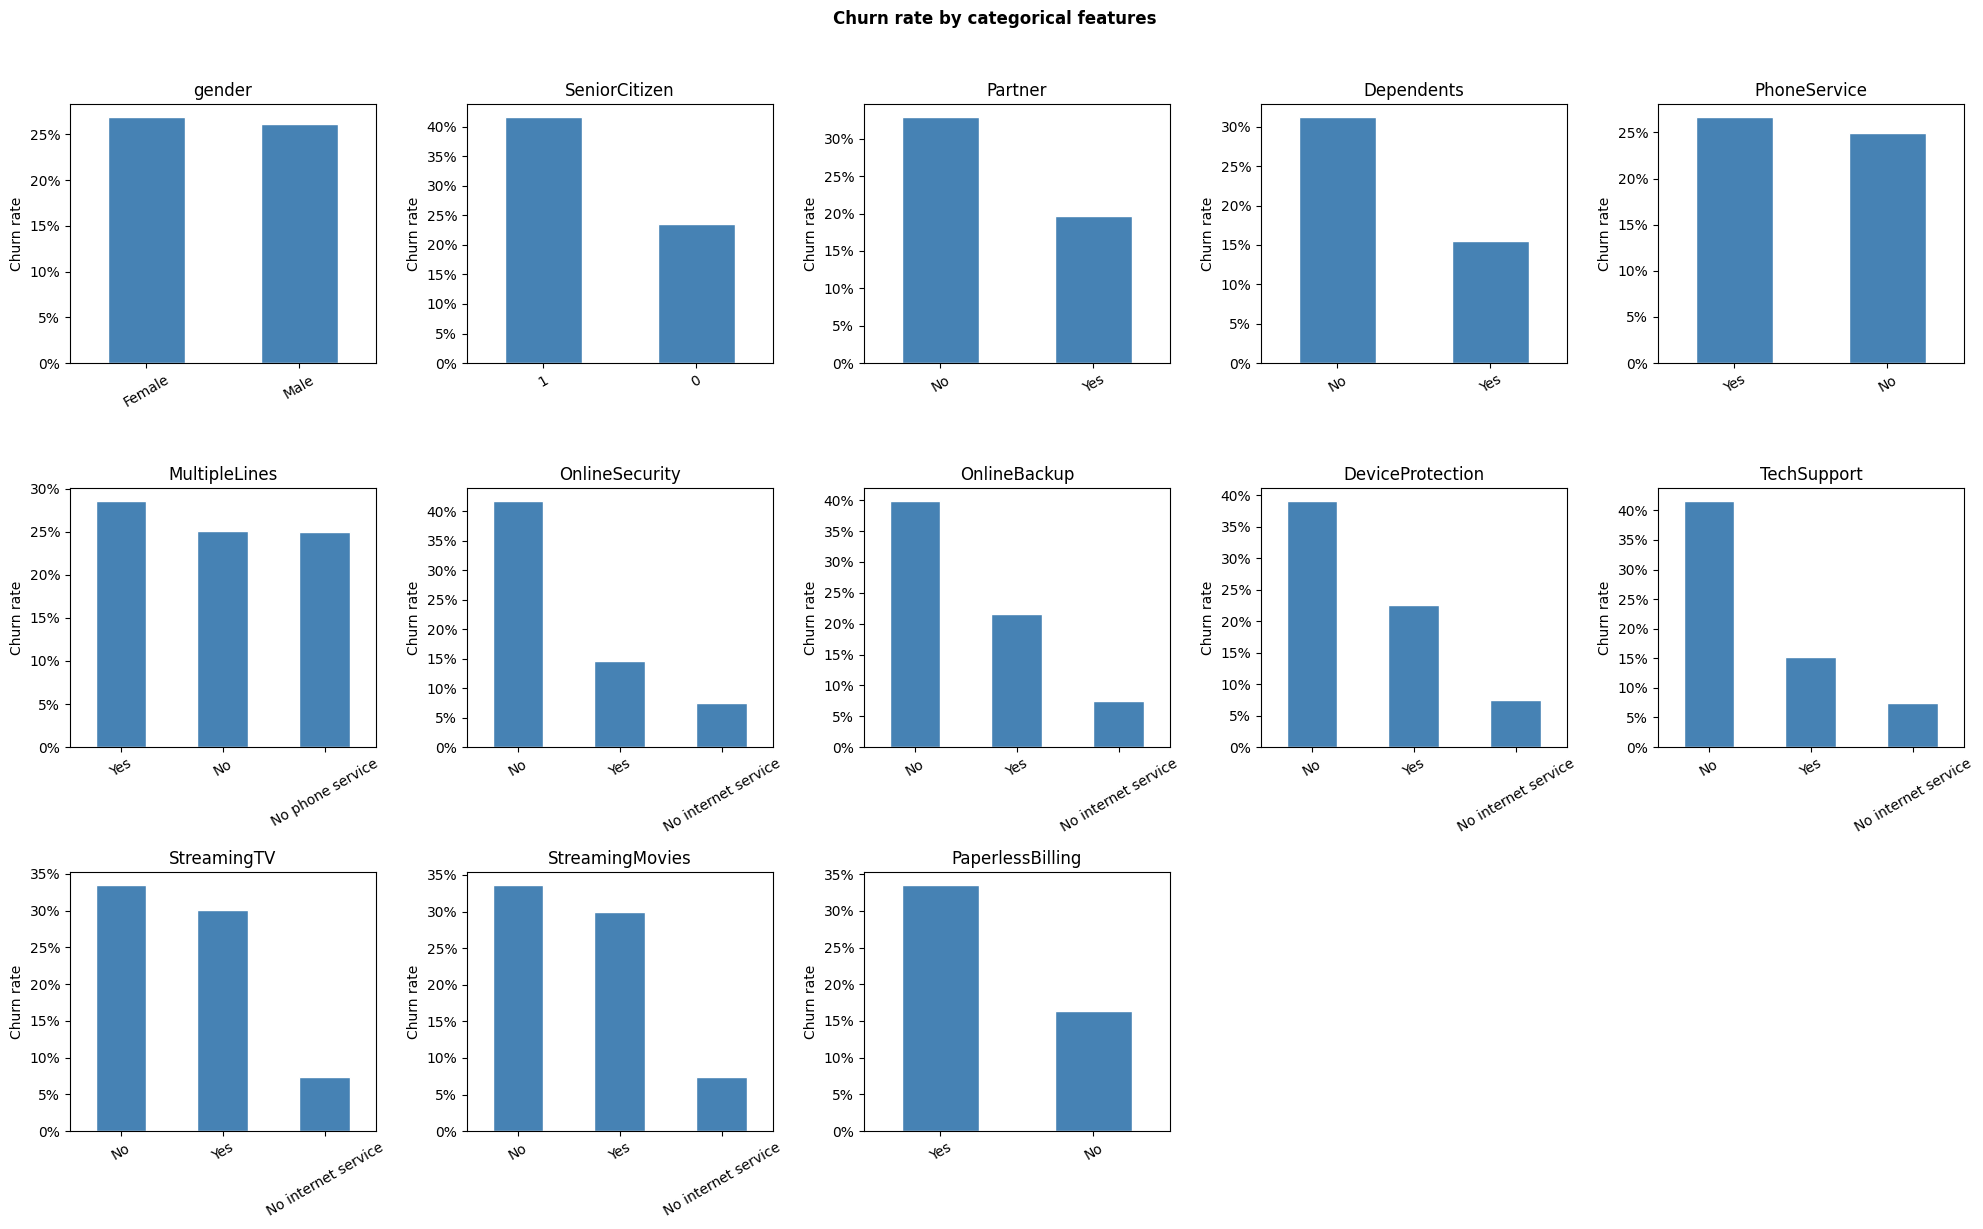

In [80]:
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
        'PhoneService', 'MultipleLines', 'OnlineSecurity', 
        'OnlineBackup', 'DeviceProtection', 'TechSupport', 
        'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Apagar el subplot sobrante
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle('Churn rate by categorical features', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**Strong signal:**
- `OnlineSecurity` — No: 41.7% vs Yes: 14.6% (~3x difference)
- `TechSupport` — No: 41.6% vs Yes: 15.2% (~3x difference)
- `OnlineBackup`, `DeviceProtection` — ~2x difference
- `SeniorCitizen` — 41.7% vs 23.6%
- `PaperlessBilling` — 33.6% vs 16.3%
- `Partner`, `Dependents` — customers without family ties churn ~2x more

**Weak signal:**
- `StreamingTV`, `StreamingMovies` — ~3–4% difference, low discriminative power
- `PhoneService`, `MultipleLines` — nearly flat

**No signal — drop candidate:**
- `gender` — 26.9% vs 26.2%. Negligible difference and ethically questionable
  to include in a scoring model.

## 6. Correlation Matrix

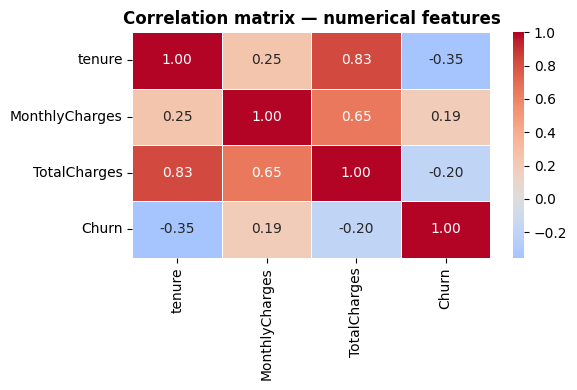

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation matrix — numerical features', fontweight='bold')
plt.tight_layout()
plt.show()

- `TotalCharges` ↔ `tenure`: 0.83 correlation — near-perfect proxy. Including both
  introduces multicollinearity. `TotalCharges` will be dropped in feature engineering.
- `tenure` ↔ `Churn`: -0.35 — strongest numerical predictor, negative relationship confirmed.
- `MonthlyCharges` ↔ `Churn`: +0.19 — higher charges, higher churn risk.

## 7. EDA Summary

| | |
|---|---|
| **Dataset** | 7,043 customers, 21 variables, 0 real nulls |
| **Churn rate** | 26.5% — 1,869 customers at risk |
| **Monthly revenue at risk** | ~AUD $121,485 |

**Top predictors identified:**

| Feature | Insight |
|---|---|
| `Contract` | Month-to-month: 42.7% churn vs Two-year: 2.8% |
| `PaymentMethod` | Electronic check: 45.3% churn |
| `InternetService` | Fiber optic: 41.9% churn |
| `OnlineSecurity` | No security: 41.7% churn |
| `TechSupport` | No support: 41.6% churn |
| `tenure` | Correlation -0.35 with churn |
| `SeniorCitizen` | 41.7% vs 23.6% |

**Feature engineering decisions:**
- **Drop:** `customerID`, `gender`, `TotalCharges`
- **Encode:** binary and one-hot for categorical variables
- **Keep & monitor:** `MonthlyCharges`, `tenure`